In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Environment ready!")
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", __import__("sklearn").__version__)


df = pd.read_csv("student_performance.csv")
df.head()

df.groupby("result")[["study_hours","attendance","assignments"]].mean()

Environment ready!
NumPy: 2.1.3
pandas: 2.2.3
scikit-learn: 1.6.1


,study_hours,attendance,assignments
result,,,
0,1.633333,65.037037,5.296296
1,3.824242,76.060606,8.393939


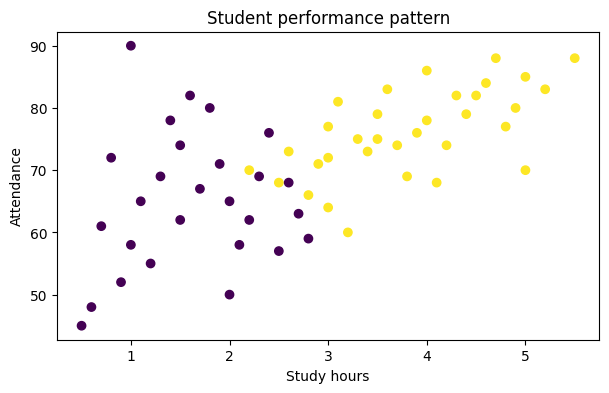

X shape: (60, 3)
y shape: (60,)
Training rows: 48
Testing rows : 12
Model trained!


In [2]:
plt.figure(figsize=(7,4))
plt.scatter(df["study_hours"], df["attendance"], c=df["result"])
plt.xlabel("Study hours")
plt.ylabel("Attendance")
plt.title("Student performance pattern")
plt.show()



X = df[["study_hours", "attendance", "assignments"]]
y = df["result"]



print("X shape:", X.shape)
print("y shape:", y.shape)



X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows :", len(X_test))

model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)

print("Model trained!")

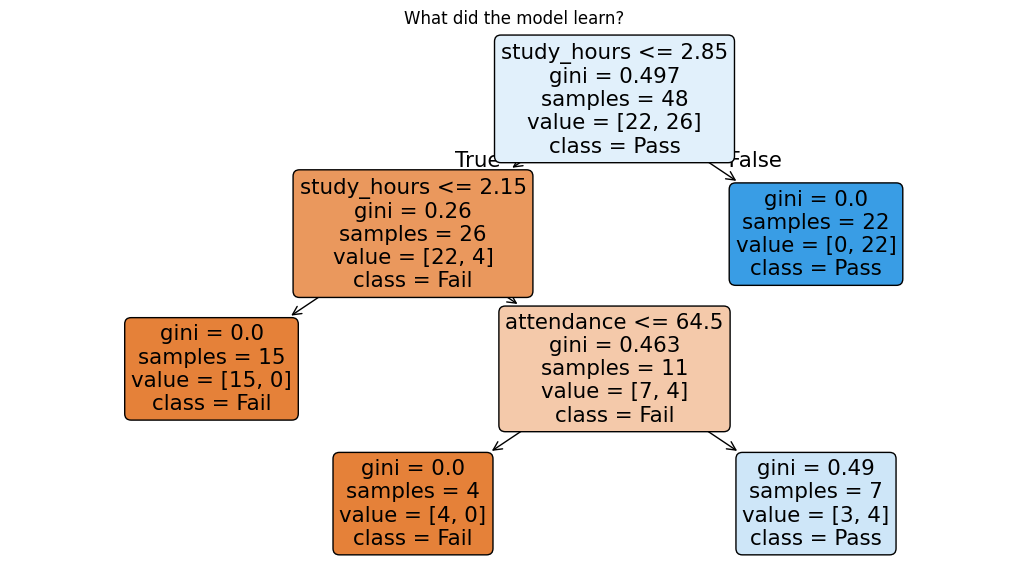

In [3]:
plt.figure(figsize=(13,7))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Fail", "Pass"],
    filled=True,
    rounded=True
)
plt.title("What did the model learn?")
plt.show()

In [4]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

# =====================================================================
# STEP 1: Prepare Sample Data (In-Memory Dataset)
# =====================================================================
# We define simple email subjects and label them as 0 (Ham/Safe) or 1 (Spam)
emails = [
    "Meeting schedule for tomorrow project review",  # Safe (0)
    "WIN FREE CASH NOW! CLICK HERE!",  # Spam (1)
    "Please send the engineering lab report by Friday",  # Safe (0)
    "Claim your free prize money today",  # Spam (1)
    "Urgent account verification required",  # Safe (0)
    "CONGRATULATIONS! You won a brand new car",  # Spam (1)
]

labels = [0, 1, 0, 1, 0, 1]  # 0 = Normal Email, 1 = Spam Email

# =====================================================================
# STEP 2: Feature Extraction (Convert Text to Numbers)
# =====================================================================
# Machine Learning algorithms work on numbers, not raw text.
# CountVectorizer counts how many times each word appears in each email.
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(emails)

# =====================================================================
# STEP 3: Train the Machine Learning Model
# =====================================================================
# We use Naive Bayes, a classic, fast algorithm for text classification.
model = MultinomialNB()
model.fit(X, labels)

print("--- Model Training Complete! ---\n")

# =====================================================================
# STEP 4: Test the Model on Unseen Email Subjects
# =====================================================================
new_emails = [
    "Submit your lab assignment tomorrow",  # Expected: Safe
    "Win a free prize and cash bonus now",  # Expected: Spam
]

# Convert new text to the exact same numerical format
X_new = vectorizer.transform(new_emails)

# Make predictions
predictions = model.predict(X_new)

# Display Results
for email, pred in zip(new_emails, predictions):
    status = "SPAM 🚨" if pred == 1 else "SAFE / NORMAL 🟢"
    print(f"Email   : '{email}'")
    print(f"Result  : {status}\n")

--- Model Training Complete! ---

Email   : 'Submit your lab assignment tomorrow'
Result  : SAFE / NORMAL 🟢

Email   : 'Win a free prize and cash bonus now'
Result  : SPAM 🚨



Student Performance Dataset:
   Study_Hours  Attendance  Assignment_Score  Previous_Score Performance
0            2          60                50              55        Fail
1            5          85                75              70        Pass
2            7          95                90              85        Pass
3            3          70                60              60        Fail
4            8          98                95              90        Pass

--------------------------------
Max Depth: 3
Accuracy: 83.33 %

Classification Report:
              precision    recall  f1-score   support

        Fail       1.00      0.50      0.67         2
        Pass       0.80      1.00      0.89         4

    accuracy                           0.83         6
   macro avg       0.90      0.75      0.78         6
weighted avg       0.87      0.83      0.81         6


--------------------------------
Max Depth: 4
Accuracy: 83.33 %

Classification Report:
              precision    r

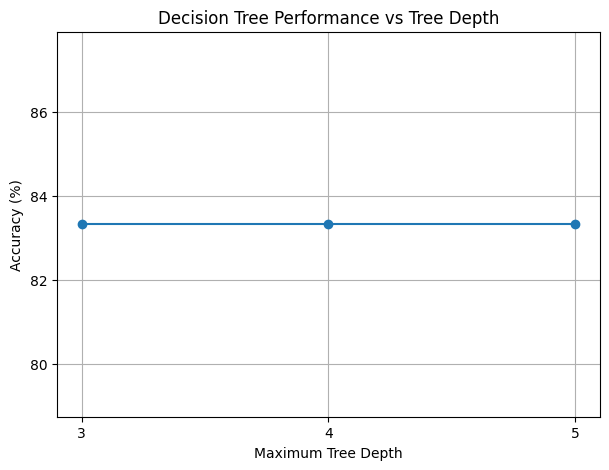

In [6]:
# Assignment 1: Decision Tree - Student Performance Prediction

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# -----------------------------------------
# 1. Create Student Performance Dataset
# -----------------------------------------

data = {
    'Study_Hours': [2, 5, 7, 3, 8, 1, 6, 4, 9, 2,
                    7, 5, 3, 8, 6, 1, 9, 4, 7, 3],

    'Attendance': [60, 85, 95, 70, 98, 50, 90, 75, 99, 65,
                   92, 88, 68, 96, 85, 55, 100, 72, 94, 62],

    'Assignment_Score': [50, 75, 90, 60, 95, 40, 85, 70, 98, 55,
                         88, 80, 58, 94, 82, 45, 97, 65, 91, 52],

    'Previous_Score': [55, 70, 85, 60, 90, 45, 80, 65, 92, 58,
                       84, 76, 62, 89, 78, 48, 94, 63, 86, 57],

    'Performance': ['Fail', 'Pass', 'Pass', 'Fail', 'Pass',
                    'Fail', 'Pass', 'Pass', 'Pass', 'Fail',
                    'Pass', 'Pass', 'Fail', 'Pass', 'Pass',
                    'Fail', 'Pass', 'Fail', 'Pass', 'Fail']
}

df = pd.DataFrame(data)

print("Student Performance Dataset:")
print(df.head())

# -----------------------------------------
# 2. Separate Features and Target
# -----------------------------------------

X = df[['Study_Hours', 'Attendance',
        'Assignment_Score', 'Previous_Score']]

y = df['Performance']

# -----------------------------------------
# 3. Split the Dataset
# -----------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# -----------------------------------------
# 4. Train Decision Trees with
#    different depths
# -----------------------------------------

depths = [3, 4, 5]
results = []

for depth in depths:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    results.append({
        'Max Depth': depth,
        'Accuracy': accuracy
    })

    print("\n--------------------------------")
    print("Max Depth:", depth)
    print("Accuracy:", round(accuracy * 100, 2), "%")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

# -----------------------------------------
# 5. Comparative Analysis
# -----------------------------------------

results_df = pd.DataFrame(results)

print("\nComparative Analysis:")
print(results_df)

# -----------------------------------------
# 6. Plot Accuracy Comparison
# -----------------------------------------

plt.figure(figsize=(7, 5))

plt.plot(
    results_df['Max Depth'],
    results_df['Accuracy'] * 100,
    marker='o'
)

plt.xlabel("Maximum Tree Depth")
plt.ylabel("Accuracy (%)")
plt.title("Decision Tree Performance vs Tree Depth")
plt.xticks([3, 4, 5])
plt.grid(True)

plt.show()

Electronics Dataset:
    Temperature_C  Power_Consumption_W
0              20                   48
1              22                   51
2              24                   53
3              26                   57
4              28                   60
5              30                   63
6              32                   66
7              34                   69
8              36                   73
9              38                   76
10             40                   80
11             42                   83
12             44                   87
13             46                   90
14             48                   94

Predicted Power Consumption:
[76.65428684 83.33702094 46.58198341]

Model Evaluation:
Mean Absolute Error: 0.8
Mean Squared Error: 0.85
R2 Score: 1.0

Linear Regression Equation:
Power Consumption = 13.17 + 1.67 * Temperature


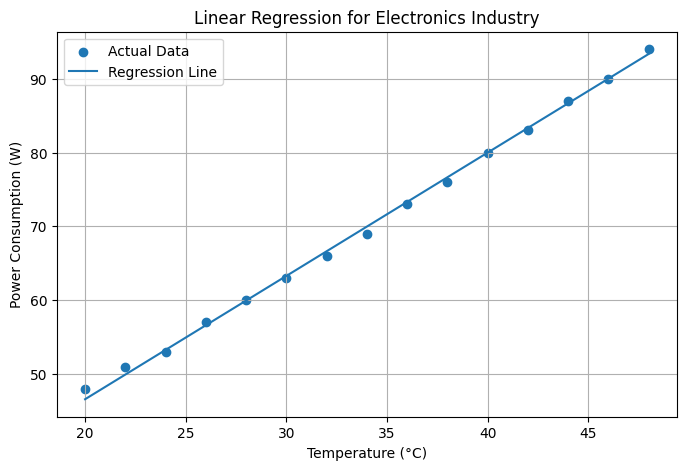

In [7]:
# Assignment 2: Linear Regression in Electronics Industry

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -----------------------------------------
# 1. Create Electronics Dataset
# -----------------------------------------

data = {
    'Temperature_C': [
        20, 22, 24, 26, 28,
        30, 32, 34, 36, 38,
        40, 42, 44, 46, 48
    ],

    'Power_Consumption_W': [
        48, 51, 53, 57, 60,
        63, 66, 69, 73, 76,
        80, 83, 87, 90, 94
    ]
}

df = pd.DataFrame(data)

print("Electronics Dataset:")
print(df)

# -----------------------------------------
# 2. Select Input and Output
# -----------------------------------------

X = df[['Temperature_C']]
y = df['Power_Consumption_W']

# -----------------------------------------
# 3. Split Data
# -----------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# -----------------------------------------
# 4. Create and Train Model
# -----------------------------------------

model = LinearRegression()

model.fit(X_train, y_train)

# -----------------------------------------
# 5. Make Predictions
# -----------------------------------------

y_pred = model.predict(X_test)

print("\nPredicted Power Consumption:")
print(y_pred)

# -----------------------------------------
# 6. Model Evaluation
# -----------------------------------------

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation:")
print("Mean Absolute Error:", round(mae, 2))
print("Mean Squared Error:", round(mse, 2))
print("R2 Score:", round(r2, 2))

# -----------------------------------------
# 7. Regression Equation
# -----------------------------------------

print("\nLinear Regression Equation:")
print(
    "Power Consumption =",
    round(model.intercept_, 2),
    "+",
    round(model.coef_[0], 2),
    "* Temperature"
)

# -----------------------------------------
# 8. Visualization
# -----------------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(
    X,
    y,
    label="Actual Data"
)

plt.plot(
    X,
    model.predict(X),
    label="Regression Line"
)

plt.xlabel("Temperature (°C)")
plt.ylabel("Power Consumption (W)")
plt.title("Linear Regression for Electronics Industry")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Assignment 3: Unsupervised Learning using K-Means

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

# -----------------------------------------
# 1. Create Customer Dataset
# -----------------------------------------

data = {
    'Annual_Income': [
        15, 18, 20, 22, 25,
        40, 42, 45, 48, 50,
        65, 68, 70, 72, 75
    ],

    'Spending_Score': [
        80, 75, 78, 82, 76,
        50, 55, 48, 52, 45,
        25, 30, 22, 28, 20
    ]
}

df = pd.DataFrame(data)

print("Customer Dataset:")
print(df)

# -----------------------------------------
# 2. Select Features
# -----------------------------------------

X = df[['Annual_Income', 'Spending_Score']]

# -----------------------------------------
# 3. Apply K-Means Clustering
# -----------------------------------------

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(X)

# -----------------------------------------
# 4. Display Results
# -----------------------------------------

print("\nClustered Data:")
print(df)

# -----------------------------------------
# 5. Display Cluster Centers
# -----------------------------------------

print("\nCluster Centers:")
print(kmeans.cluster_centers_)

# -----------------------------------------
# 6. Visualization
# -----------------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(
    df['Annual_Income'],
    df['Spending_Score'],
    c=df['Cluster'],
    s=100
)

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker='X',
    s=200,
    label='Cluster Centers'
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation using K-Means")
plt.legend()
plt.grid(True)

plt.show()